In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv(r'C:\Users\HP\Downloads\Data Analytics Projects\Final Projects\Telecom_Churn_Analysis\outputs\cleaned_data.csv')

In [3]:
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Tenure Groups,Risk Level,Churned_Flag
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,9,NaN,Yes,42.39,No,Yes,Cable,16.0,No,Yes,No,Yes,Yes,No,No,Yes,One Year,Yes,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN,0-12 Months,Low Risk,0
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,9,NaN,Yes,10.69,Yes,Yes,Cable,10.0,No,No,No,No,No,Yes,Yes,No,Month-to-Month,No,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN,0-12 Months,Low Risk,0
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,4,Offer E,Yes,33.65,No,Yes,Fiber Optic,30.0,No,No,Yes,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices,0-12 Months,High Risk,1
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,13,Offer D,Yes,27.82,No,Yes,Fiber Optic,4.0,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction,13-24 Months,High Risk,1
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,3,NaN,Yes,7.38,No,Yes,Fiber Optic,11.0,No,No,No,Yes,Yes,No,No,Yes,Month-to-Month,Yes,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability,0-12 Months,High Risk,1


In [8]:
#overall churn rate 
# Overall Churn Rate

churn_rate = (df['Churned_Flag'].mean()) * 100

print(f'Overall Churn Rate: {churn_rate:.2f}%')

Overall Churn Rate: 26.54%


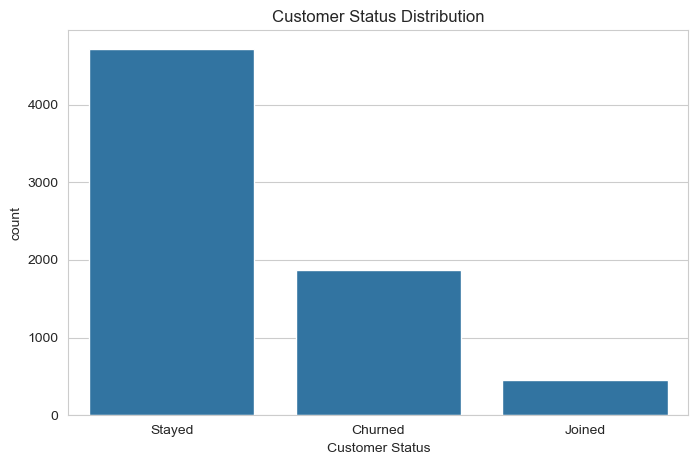

In [9]:
#Customer Status Distribution 
plt.figure(figsize = (8,5))
sns.countplot(
    data = df, 
    x = 'Customer Status'
)
plt.title('Customer Status Distribution')
plt.show()

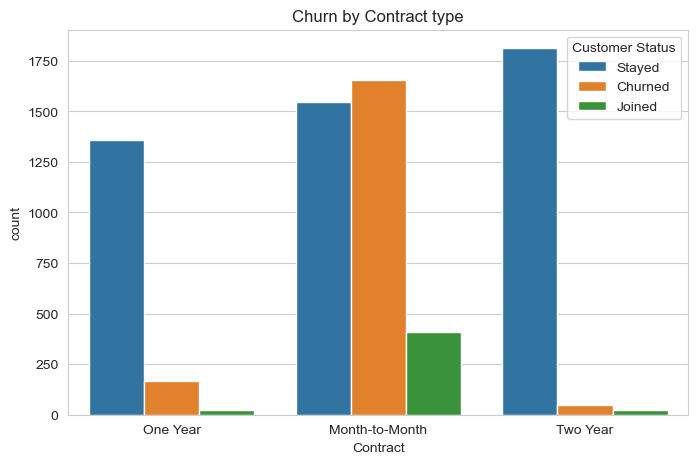

In [11]:
#Churn by contract type 
plt.figure(figsize = (8,5))
sns.countplot(
    data = df, 
    x = 'Contract',
    hue = 'Customer Status'
)
plt.title('Churn by Contract type')
plt.show()

#Note: Month -to- Month churn significantly more than yearly contract 

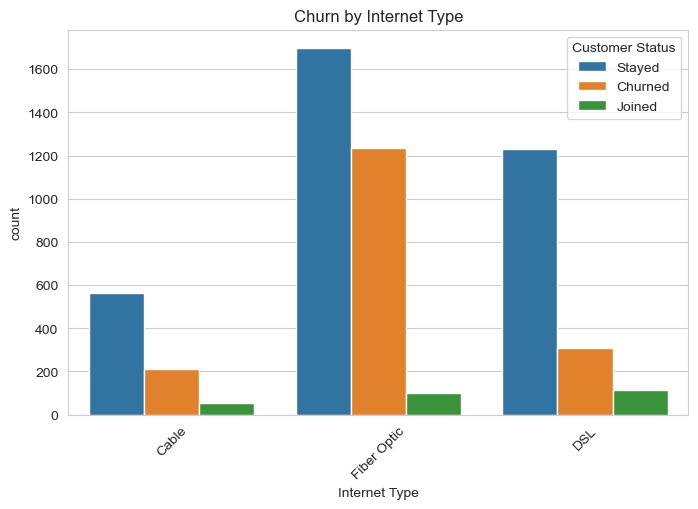

In [12]:
#churn by internet type 
plt.figure(figsize = (8,5))
sns.countplot(
    data = df,
    x = 'Internet Type',
    hue = 'Customer Status'
)
plt.xticks (rotation = 45)
plt.title ('Churn by Internet Type')
plt.show()

#note: Fibre optics show higher churn suggesting disatsifaction despite premium servies 

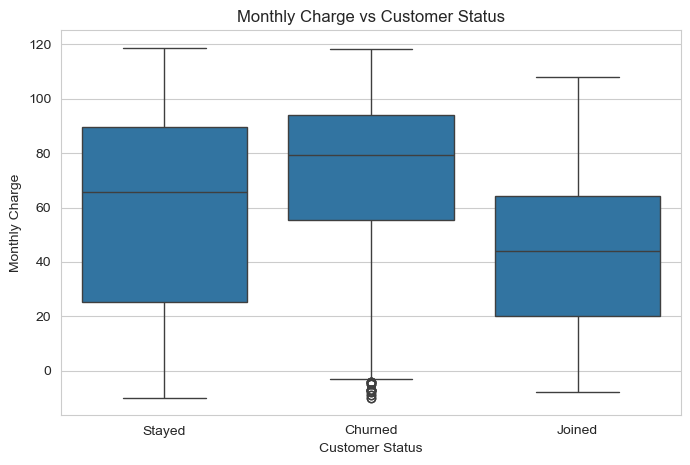

In [16]:
#Monthly charges vs churn 
# Monthly charges vs churn

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Customer Status',
    y='Monthly Charge'
)

plt.title('Monthly Charge vs Customer Status')

plt.show()

#Note: Customers paying higher monthly charges tends to churn more frequently 

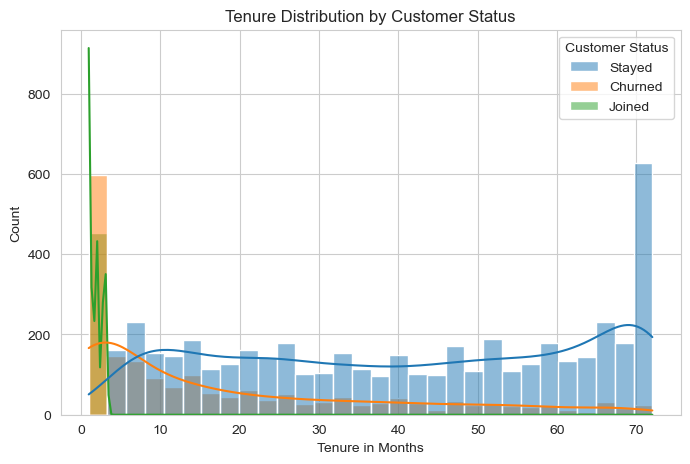

In [17]:
#Tenure Distribution 
plt.figure(figsize = (8,5))
sns.histplot(
    data = df, 
    x = 'Tenure in Months',
    hue = 'Customer Status',
    bins = 30,
    kde = True
)
plt.title('Tenure Distribution by Customer Status')
plt.show()

#Customer with lower tenure are more likely to churn 

AttributeError: Text.set() got an unexpected keyword argument 'rotate'

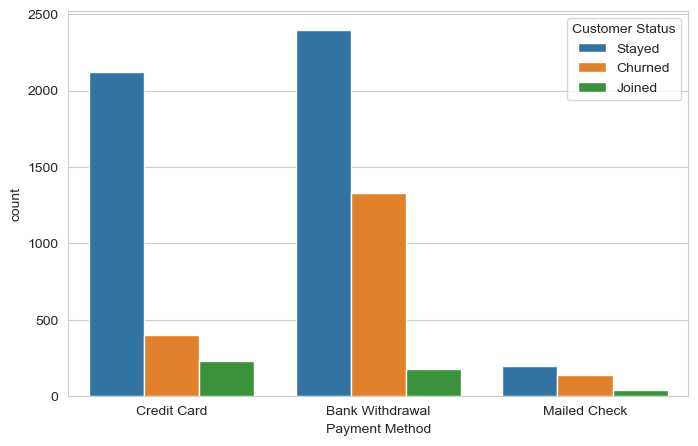

In [20]:
#Payment method analysis 

plt.figure(figsize= (8,5))
sns.countplot(
    data = df, 
    x = 'Payment Method',
    hue = 'Customer Status'
)
plt.xticks(rotate=45)
plt.title('Churn by Payment Method')
plt.show()

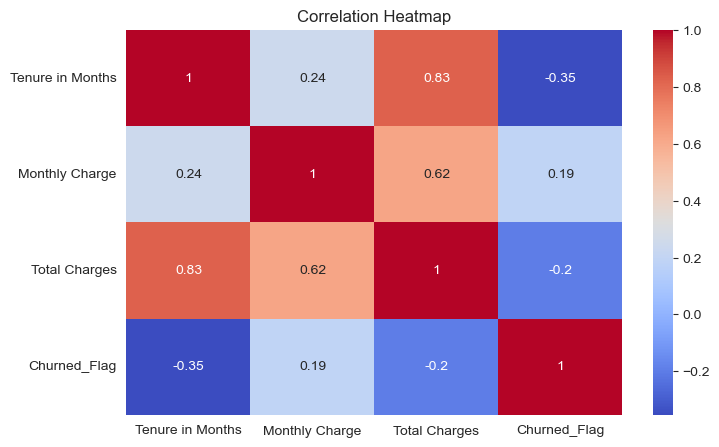

In [26]:
# Correlation Heatmap

plt.figure(figsize=(8,5))

correlation = df[
    ['Tenure in Months',
     'Monthly Charge',
     'Total Charges',
     'Churned_Flag']
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [28]:
#Top churn Reasons 

top_reasons = df[
   df['Customer Status'] == 'Churned'
]['Churn Reason'].value_counts().head(10)
print(top_reasons)

Churn Reason
Competitor had better devices                313
Competitor made better offer                 311
Attitude of support person                   220
Don't know                                   130
Competitor offered more data                 117
Competitor offered higher download speeds    100
Attitude of service provider                  94
Price too high                                78
Product dissatisfaction                       77
Network reliability                           72
Name: count, dtype: int64


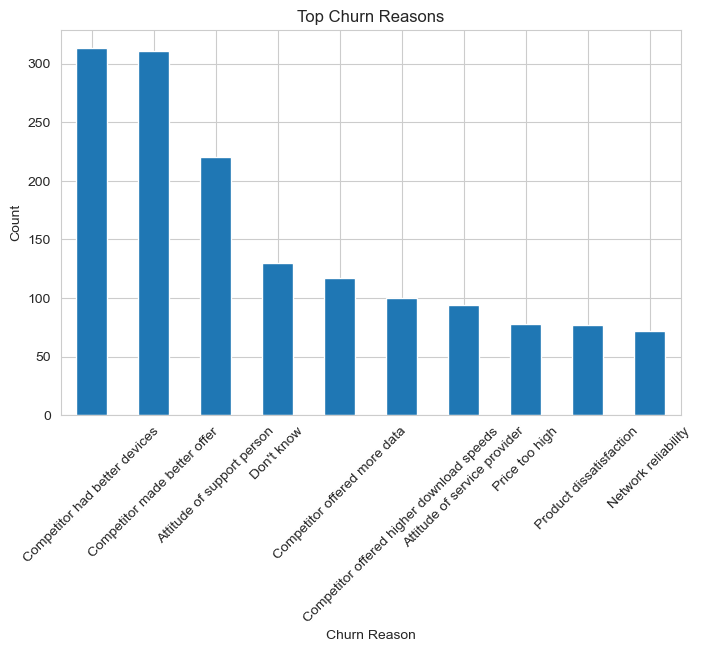

In [29]:
#Churn Reason Visualization 
plt.figure(figsize = (8,5))
top_reasons.plot(kind = 'bar')
plt.title('Top Churn Reasons')
plt.ylabel('Count')
plt.xticks(rotation =45)
plt.show()
                 

In [31]:
#Revenue loss Estimation 

revenue_loss = df[
   df['Customer Status'] == 'Churned'
]['Monthly Charge'].sum()
print(f'Total Revenue Loss: ${revenue_loss:.2f}')

Total Revenue Loss: $137086.65
